PROJECT — Titanic Data Analysis

Load the dataset with this code:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)


--- SECTION 1: Explore the Data ---

1. Display the first 5 rows. What columns do you see?

2. Use .info() — how many rows and columns does the dataset have?

3. Use .isnull().sum() to check for missing values. Which columns have missing data?


--- SECTION 2: Clean the Data ---

4. Fill missing Age values with the median age.

5. Drop the Cabin column (too many missing values to be useful).

6. Confirm there are no more missing values in the columns you fixed.


--- SECTION 3: Analyse the Data ---

7. What is the overall survival rate? (Hint: titanic['Survived'].mean())

8. What is the survival rate for males vs females? Which group survived more?

9. What is the survival rate for each passenger class (1st, 2nd, 3rd)?

10. What is the average fare paid by each passenger class?


--- SECTION 4: Visualise the Data ---

11. Create a countplot showing how many passengers survived vs did not survive.

12. Create a histogram of passenger ages, with survivors and non-survivors in different colors.

13. Create a boxplot of fares grouped by passenger class.


--- SECTION 5: Think About It ---

Answer in a comment using # in your code.

14. Which passengers were most likely to survive? List at least two factors from your analysis.

15. Why do you think 1st class passengers survived more than 3rd class?


--- BONUS (if you finish early) ---

16. Create a FamilySize column: SibSp + Parch + 1. Did passengers with family survive more than those travelling alone?

In [45]:
import pandas as pd
import numpy as np

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
Titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [48]:
# 1. Display the first 5 rows. What columns do you see?

Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 2. Use .info() — how many rows and columns does the dataset have?

Titanic.info()

# The Dataset has 12 Columns and 891 Rows

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# 3. Use .isnull().sum() to check for missing values. Which columns have missing data?

Titanic.isnull().sum()

# 3 Columns has missing datasets. Age has 177, Cabin has 687 and Embarked has 2. 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- SECTION 2: Clean the Data ---

In [ ]:
# 4. Fill missing Age values with the median age.

Titanic['Age'] = Titanic['Age'].fillna(Titanic['Age'].median())

# Titanic.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [57]:
# 5. Drop the Cabin column (too many missing values to be useful).

Titanic = Titanic.drop(columns=['Cabin'])

In [60]:
# 6. Confirm there are no more missing values in the columns you fixed.

Titanic[['Age']].isnull().sum()

Titanic.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

--- SECTION 3: Analyse the Data ---

In [ ]:
# 7. What is the overall survival rate? (Hint: titanic['Survived'].mean())

print("Overall Survival Rate is:", Titanic['Survived'].mean())


Overall Survival Rate is: 0.3838383838383838


In [ ]:
# 8. What is the survival rate for males vs females? Which group survived more?

print("Survival Rate for Male and Female is:", Titanic.groupby('Sex')['Survived'].mean())

Survival Rate for Male and Female is: Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [66]:
# 9. What is the survival rate for each passenger class (1st, 2nd, 3rd)?

print("Survival Rate for each Passenger is:", Titanic.groupby('Pclass')['Survived'].mean())

Survival Rate for each Passenger is: Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [68]:
# 10. What is the average fare paid by each passenger class?

print("The Average fare paid by each passenger class is:", Titanic.groupby('Pclass')['Fare'].mean())

The Average fare paid by each passenger class is: Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


--- SECTION 4: Visualise the Data ---

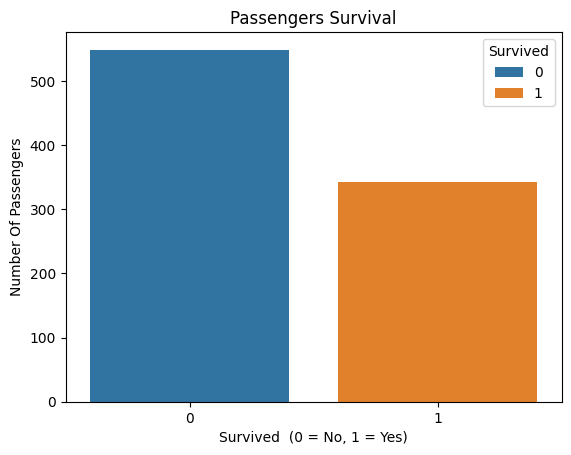

In [75]:
# 11. Create a countplot showing how many passengers survived vs did not survive.

sns.countplot(data=Titanic, x='Survived', hue='Survived' )
plt.title('Passengers Survival')
plt.xlabel('Survived  (0 = No, 1 = Yes)')
plt.ylabel('Number Of Passengers')
plt.show()

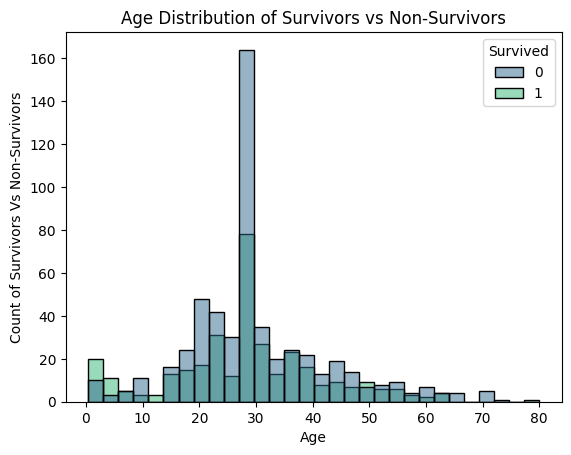

In [98]:
# 12. Create a histogram of passenger ages, with survivors and non-survivors in different colors.


plt.Figure(figsize=(10, 7))
sns.histplot(data=Titanic, x='Age', hue='Survived', bins=30, palette='viridis')
plt.title('Age Distribution of Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count of Survivors Vs Non-Survivors')
plt.show()

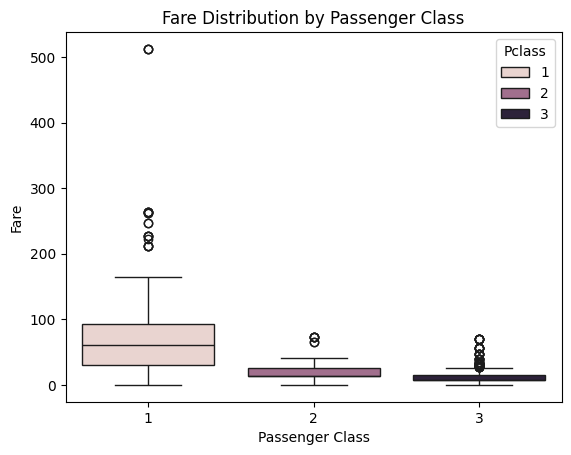

In [ ]:
# 13. Create a boxplot of fares grouped by passenger class.

plt.Figure(figsize=(15, 13))
sns.boxplot(data=Titanic, x='Pclass', y='Fare', hue='Pclass')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()


--- SECTION 5: Think About It ---

In [ ]:
# Answer in a comment using # in your code.

# 14. Which passengers were most likely to survive? List at least two factors from your analysis.

# 1. Gender (Females were far more likely to survive)
# My calculation showed:

# Female survival rate: ~74%

# Male survival rate: ~19%

# This is the strongest predictor in the entire dataset.

# The “women and children first” evacuation policy played a huge role.

# 2. Passenger Class (1st class survived the most)
# From my class‑based survival rates:

# 1st class: ~63% survived

# 2nd class: ~47% survived

# 3rd class: ~24% survived




In [ ]:

# 15. Why do you think 1st class passengers survived more than 3rd class?

# 1. Physical proximity to lifeboats
# 1st class cabins were located on the upper decks, much closer to the lifeboats.
# 3rd class passengers were mostly on the lower decks, far from the boat deck.

# In an emergency where minutes mattered, this distance made a huge difference.

# Higher‑class passengers were physically closer to the lifeboats and had better access to the deck.

--- BONUS (if you finish early) ---

In [ ]:
# 16. Create a FamilySize column: SibSp + Parch + 1. 


Titanic['FamilySize'] = Titanic['SibSp'] + Titanic['Parch'] + 1

Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


In [ ]:
# Did passengers with family survive more than those travelling alone?

Titanic.groupby(Titanic['FamilySize'] > 1)['Survived'].mean()

# Families greater than one survived more maybe becausde they were able to help each other and 
# also in many cases the crew always favored passengers travelling with children, 
# that also could be the reason.

FamilySize
False    0.303538
True     0.505650
Name: Survived, dtype: float64